# **Model Sentimen Analisis Review Aplikasi Shopee di Play Store**


In [1]:
!pip install sastrawi
!pip install wordcloud
!pip install requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.5 MB/s eta 0:00:00


# **Import Library**

In [2]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas

import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
import nltk
import requests
import csv
import tensorflow as tf

from google.colab import drive

from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks
from nltk.stem import WordNetLemmatizer
from nltk import download as nltk_download

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

from imblearn.over_sampling import SMOTE

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Conv1D, GlobalMaxPooling1D, Bidirectional, MaxPooling1D, Flatten, GRU, SimpleRNN, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

from io import StringIO


In [3]:
nltk.download('punkt_tab')
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Loading Dataset

In [4]:
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Project_Sentimen/ulasan_apl_shoppe (1).csv"
data = pd.read_csv(file_path)
data.head()


Mounted at /content/drive


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,697b441c-9de7-489e-a870-e07b88eed2ac,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya tidak suka dengan aplikasi shopee yg seka...,1,127,3.47.40,2025-04-10 11:48:12,"Hai kak Fitra Muhammad, terima kasih ya untuk ...",2025-04-10 12:35:26,3.47.40
1,2afeff66-3c72-4514-9b42-324732c66fb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Status ""Dalam pengantaran"" tapi di tunggu gak ...",2,13,3.47.40,2025-04-12 10:27:10,"Hai kak Dedes Ayss, maaf ya udah buat risau te...",2025-04-12 11:10:37,3.47.40
2,6a4985ba-01a7-4bb3-8eb7-4063be306f6c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kembalikan jnt express. jasa kirim spxexpress ...,1,81,3.47.40,2025-04-10 18:13:22,"Hai kak Maulana Ahsani , maaf ya sudah bkin km...",2025-04-10 19:17:45,3.47.40
3,ab764998-d9e3-4ef6-ba70-39b443b467f1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semenjak update app shopee hp sering mati sndi...,1,34,3.47.40,2025-04-09 23:13:07,NaN,NaN,3.47.40
4,87c3a101-6ebc-4a50-8bbf-e656f6ce2dd3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Menurut ku aplikasi ini sangat membantu... Han...,1,34,3.47.40,2025-04-10 03:34:36,Hi kak maaf buat km gak nyaman terkait kendala...,2024-09-22 10:42:21,3.47.40


In [5]:
data.shape

(94500, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94500 entries, 0 to 94499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              94500 non-null  object
 1   userName              94500 non-null  object
 2   userImage             94500 non-null  object
 3   content               94500 non-null  object
 4   score                 94500 non-null  int64 
 5   thumbsUpCount         94500 non-null  int64 
 6   reviewCreatedVersion  80986 non-null  object
 7   at                    94500 non-null  object
 8   replyContent          70206 non-null  object
 9   repliedAt             70206 non-null  object
 10  appVersion            80986 non-null  object
dtypes: int64(2), object(9)
memory usage: 7.9+ MB


#Insight

1. Terdapat missing value pada kolom
- reviewCreatedVersion
- replyContent
- repliedAt
- appVersion


In [7]:
#Menghapus data duplikat
clean_data = data.drop_duplicates()

In [8]:
clean_data = data.dropna()

In [9]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61357 entries, 0 to 94499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              61357 non-null  object
 1   userName              61357 non-null  object
 2   userImage             61357 non-null  object
 3   content               61357 non-null  object
 4   score                 61357 non-null  int64 
 5   thumbsUpCount         61357 non-null  int64 
 6   reviewCreatedVersion  61357 non-null  object
 7   at                    61357 non-null  object
 8   replyContent          61357 non-null  object
 9   repliedAt             61357 non-null  object
 10  appVersion            61357 non-null  object
dtypes: int64(2), object(9)
memory usage: 5.6+ MB


##Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [10]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwors in a text
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

    return stemmed_text
def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [11]:
slangwords = {
    "@": "di",
    'g': "ga",
    'ga': 'tidak',
    'gak': 'tidak',
    'gk': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'tdk': 'tidak',
    'bgt': 'banget',
    'bngt': 'banget',
    'aja': 'saja',
    'aj': 'saja',
    'jg': 'juga',
    'udh': 'sudah',
    'udh2': 'sudah',
    'udhya': 'sudah',
    'udhyaaa': 'sudah',
    'dpt': 'dapat',
    'dptin': 'dapatkan',
    'dptnya': 'dapatnya',
    'brg': 'barang',
    'bgt': 'banget',
    'telat': 'terlambat',
    'trm': 'terima',
    'trus': 'terus',
    'dgn': 'dengan',
    'sm': 'sama',
    'tp': 'tapi',
    'krn': 'karena',
    'trs': 'terus',
    'dgn': 'dengan',
    'sdh': 'sudah',
    'sy': 'saya',
    'knp': 'kenapa',
    'sm': 'sama',
    'tp': 'tapi',
    'krn': 'karena',
    'klo': 'kalau',
    'terimakasih':'terima kasih',
    'kl': 'kalau',
    'blm': 'belum',
    'kmrn': 'kemarin',
    'dr': 'dari',
    'dtg': 'datang',
    'nnti': 'nanti',
    'udh': 'sudah',
    'skrg': 'sekarang',
    'bsk': 'besok',
    'td': 'tadi',
    'knp': 'kenapa',
    'knpnya': 'kenapa',
    'ngeselin': 'kesal',
    'responny': 'responnya',
    'mksh': 'terima kasih',
    'mkasih': 'terima kasih',
    'mksih': 'terima kasih',
    'makasih': 'terima kasih',
    'thx': 'terima kasih',
    'thanks': 'terima kasih',
    'trimakasih': 'terima kasih',
    'ok': 'oke',
    'oke': 'baik',
    'okey': 'baik',
    'ud':'sudah',
    'cs':'costumer service',
    'pickup':'pick up',
    'jga':'juga',
    'lu':'kamu',
    'gimna': 'gimana',
    'karna':'karena',
    'banget':'sangat',
    'sip': 'baik',
    'bgus': 'bagus',
    'br': 'baru',
    'utk':'untuk',
    'lgsng': 'langsung',
    'cepet': 'cepat',
    'burik': 'bukan',
    'bkn': 'bukan',
    'cape': 'lelah',
    'tetep':'tetap',
    'gini': 'ini',
    'lg':'lagi',
    'bikin': 'membuat',
    'cpt': 'cepat',
    'lamaa': 'lama',
    'lemot': 'lambat',
    'batalin': 'batalkan',
    'cancelin': 'batalkan',
    'murce': 'murah',
    'diskonny': 'diskonnya',
    'sellerny': 'sellernya',
    'pelayananny': 'pelayanannya',
    'jd': 'jadi',
    'yg':'yang',
    'tdk':'tidak',
    'sndiri':'sendiri',
    'smakin' :'semakin',
}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [12]:
clean_df=clean_data
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,697b441c-9de7-489e-a870-e07b88eed2ac,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya tidak suka dengan aplikasi shopee yg seka...,1,127,3.47.40,2025-04-10 11:48:12,"Hai kak Fitra Muhammad, terima kasih ya untuk ...",2025-04-10 12:35:26,3.47.40
1,2afeff66-3c72-4514-9b42-324732c66fb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Status ""Dalam pengantaran"" tapi di tunggu gak ...",2,13,3.47.40,2025-04-12 10:27:10,"Hai kak Dedes Ayss, maaf ya udah buat risau te...",2025-04-12 11:10:37,3.47.40
2,6a4985ba-01a7-4bb3-8eb7-4063be306f6c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kembalikan jnt express. jasa kirim spxexpress ...,1,81,3.47.40,2025-04-10 18:13:22,"Hai kak Maulana Ahsani , maaf ya sudah bkin km...",2025-04-10 19:17:45,3.47.40
4,87c3a101-6ebc-4a50-8bbf-e656f6ce2dd3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Menurut ku aplikasi ini sangat membantu... Han...,1,34,3.47.40,2025-04-10 03:34:36,Hi kak maaf buat km gak nyaman terkait kendala...,2024-09-22 10:42:21,3.47.40
5,2c896624-39b7-4e74-b0ec-5dc7b3cc1d0d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Yang saya suka dari shopee: 1. metode pembayar...,3,8,3.47.39,2025-04-12 05:41:05,"Hi kak david aero zaki, makasih ya buat feedba...",2025-04-12 06:16:02,3.47.39


In [13]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [14]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,697b441c-9de7-489e-a870-e07b88eed2ac,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya tidak suka dengan aplikasi shopee yg seka...,1,127,3.47.40,2025-04-10 11:48:12,"Hai kak Fitra Muhammad, terima kasih ya untuk ...",2025-04-10 12:35:26,3.47.40,saya tidak suka dengan aplikasi shopee yg seka...,saya tidak suka dengan aplikasi shopee yg seka...,saya tidak suka dengan aplikasi shopee yang se...,"[saya, tidak, suka, dengan, aplikasi, shopee, ...","[suka, aplikasi, shopee, buka, aplikasi, langs...",suka aplikasi shopee buka aplikasi langsung me...
1,2afeff66-3c72-4514-9b42-324732c66fb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Status ""Dalam pengantaran"" tapi di tunggu gak ...",2,13,3.47.40,2025-04-12 10:27:10,"Hai kak Dedes Ayss, maaf ya udah buat risau te...",2025-04-12 11:10:37,3.47.40,Status Dalam pengantaran tapi di tunggu gak ad...,status dalam pengantaran tapi di tunggu gak ad...,status dalam pengantaran tapi di tunggu tidak ...,"[status, dalam, pengantaran, tapi, di, tunggu,...","[status, pengantaran, tunggu, kurir, status, b...",status pengantaran tunggu kurir status berubah...
2,6a4985ba-01a7-4bb3-8eb7-4063be306f6c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kembalikan jnt express. jasa kirim spxexpress ...,1,81,3.47.40,2025-04-10 18:13:22,"Hai kak Maulana Ahsani , maaf ya sudah bkin km...",2025-04-10 19:17:45,3.47.40,kembalikan jnt express jasa kirim spxexpress s...,kembalikan jnt express jasa kirim spxexpress s...,kembalikan jnt express jasa kirim spxexpress s...,"[kembalikan, jnt, express, jasa, kirim, spxexp...","[kembalikan, jnt, express, jasa, kirim, spxexp...",kembalikan jnt express jasa kirim spxexpress l...
4,87c3a101-6ebc-4a50-8bbf-e656f6ce2dd3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Menurut ku aplikasi ini sangat membantu... Han...,1,34,3.47.40,2025-04-10 03:34:36,Hi kak maaf buat km gak nyaman terkait kendala...,2024-09-22 10:42:21,3.47.40,Menurut ku aplikasi ini sangat membantu Hanya ...,menurut ku aplikasi ini sangat membantu hanya ...,menurut ku aplikasi ini sangat membantu hanya ...,"[menurut, ku, aplikasi, ini, sangat, membantu,...","[aplikasi, membantu, penjual, aamanah, aplikas...",aplikasi membantu penjual aamanah aplikasi sup...
5,2c896624-39b7-4e74-b0ec-5dc7b3cc1d0d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Yang saya suka dari shopee: 1. metode pembayar...,3,8,3.47.39,2025-04-12 05:41:05,"Hi kak david aero zaki, makasih ya buat feedba...",2025-04-12 06:16:02,3.47.39,Yang saya suka dari shopee metode pembayaran ...,yang saya suka dari shopee metode pembayaran ...,yang saya suka dari shopee metode pembayaran y...,"[yang, saya, suka, dari, shopee, metode, pemba...","[suka, shopee, metode, pembayaran, flexible, h...",suka shopee metode pembayaran flexible harga t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94488,a917bea8-8633-4ec6-9812-11aeb3159ac3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Apasih gejelas banget, vocher belum di pakai s...",1,16,3.04.20,2023-09-08 17:16:24,Hai kak. Maaf terkait Kode Voucher yang sudah ...,2023-08-18 04:12:38,3.04.20,Apasih gejelas banget vocher belum di pakai su...,apasih gejelas banget vocher belum di pakai su...,apasih gejelas sangat vocher belum di pakai su...,"[apasih, gejelas, sangat, vocher, belum, di, p...","[apasih, gejelas, vocher, pakai, habis, tolong...",apasih gejelas vocher pakai habis tolong diper...
94489,7702286b-0e20-4c22-8043-1a649e13ac41,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Makin kesini makin banyak biaya ini itu, pelit...",2,11,2.95.20,2022-11-18 15:24:30,"Hai Ritma, terima kasih atas rating bintang 5 ...",2017-05-24 09:10:23,2.95.20,Makin kesi

##Pelabelan

Mengunduh lexion positive dan negative dari Github

In [15]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")


Mendefinisikan fungsi untuk polaritas sentimen dari tweet

In [16]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score <=-8):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
        # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

Hasil Pelabelan

In [17]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    33128
neutral     18016
negative    10213
Name: count, dtype: int64


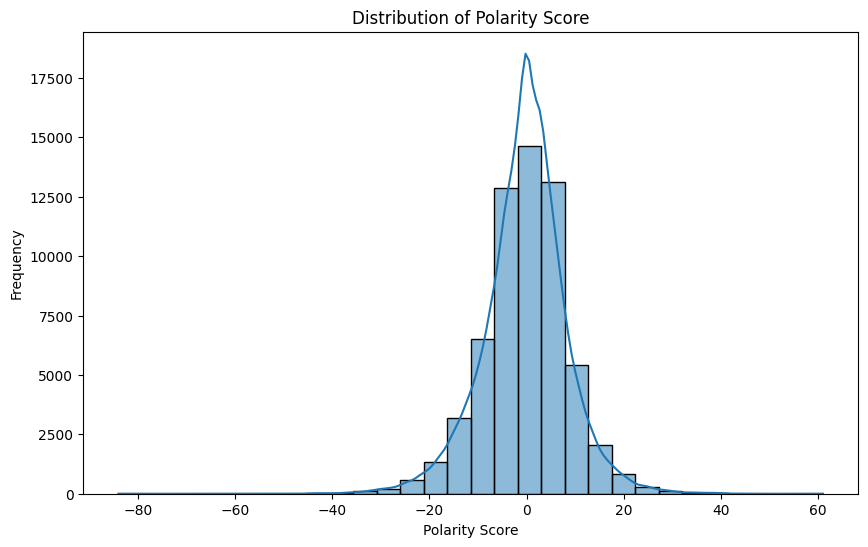

In [18]:
# Menampilkan distribusi polarity_score dengan histogram
plt.figure(figsize=(10, 6))
sns.histplot(clean_df['polarity_score'], bins=30, kde=True)
plt.title('Distribution of Polarity Score')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.show()

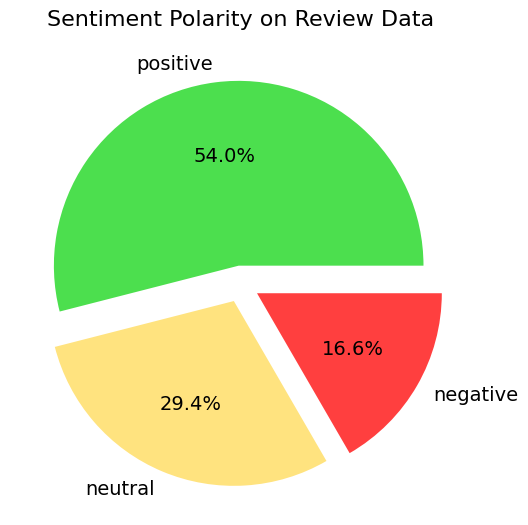

In [19]:
# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci.
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data polaritas sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'sizes'.
sizes = [count for count in clean_df['polarity'].value_counts()]

# Mengambil label atau kategori sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'labels'.
labels = list(clean_df['polarity'].value_counts().index)

# Menentukan seberapa jauh potongan dari pie chart akan ditarik (0.1 artinya potongan pertama akan sedikit terpisah).
explode = (0.1, 0.1,0.1)

# Membuat pie chart dengan data 'sizes', 'labels', dan 'explode' yang telah ditentukan.
# Autopct digunakan untuk menampilkan persentase di dalam setiap potongan pie.
# Textprops digunakan untuk mengatur ukuran font teks dalam pie chart.
colors = ['#4cdf4e','#FFE37F', '#ff3f3f']
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14}, colors=colors)

# Menetapkan judul untuk pie chart dengan ukuran font dan jarak (padding) tertentu.
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

In [20]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [21]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

In [22]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'neutral_tweets' yang hanya berisi tweet dengan polaritas negatif.
neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'neutral_tweets'.
neutral_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'neutral_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
neutral_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
neutral_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
neutral_tweets = neutral_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
neutral_tweets.index += 1

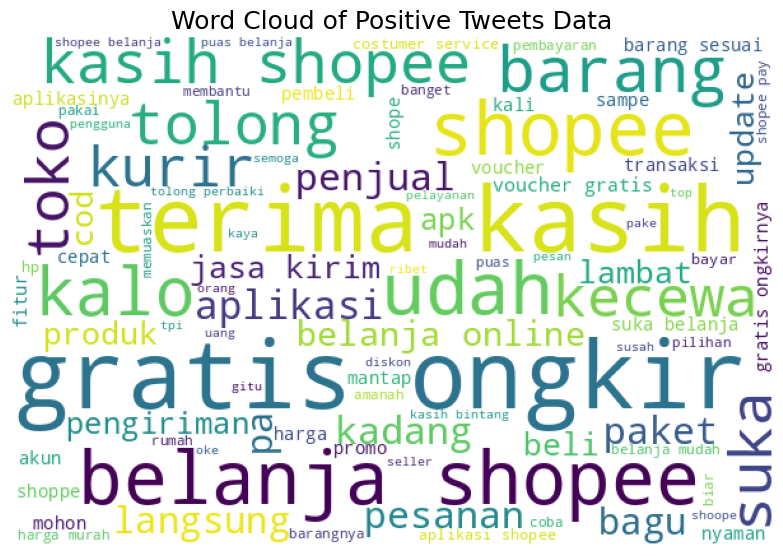

In [23]:
# Menggabungkan semua kata dalam 'text_stopword' jadi satu string besar secara efisien
list_words = ' '.join([' '.join(tweet) for tweet in positive_tweets['text_stopword']])

# Membuat WordCloud
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


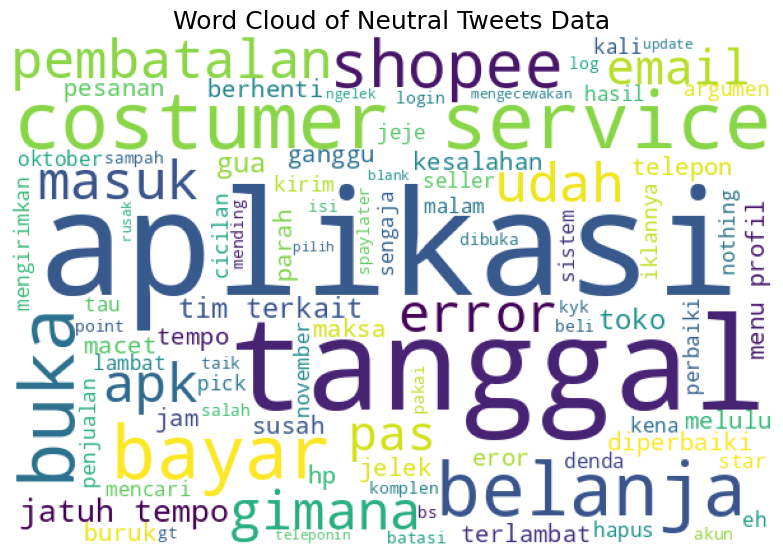

In [24]:
# Menggabungkan semua kata dalam 'text_stopword' jadi satu string besar secara efisien
list_words = ' '.join([' '.join(tweet) for tweet in neutral_tweets['text_stopword']])

# Membuat WordCloud
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


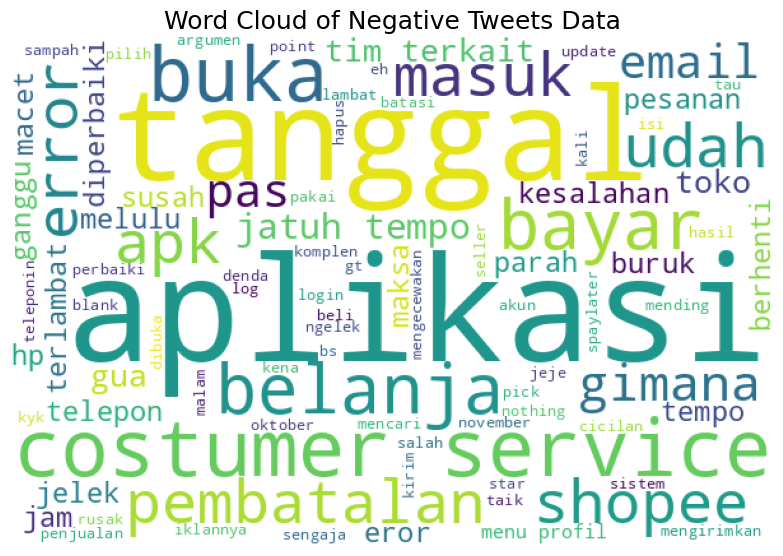

In [25]:
# Menggabungkan semua kata dalam 'text_stopword' jadi satu string besar secara efisien
list_words = ' '.join([' '.join(tweet) for tweet in negative_tweets['text_stopword']])

# Membuat WordCloud
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()


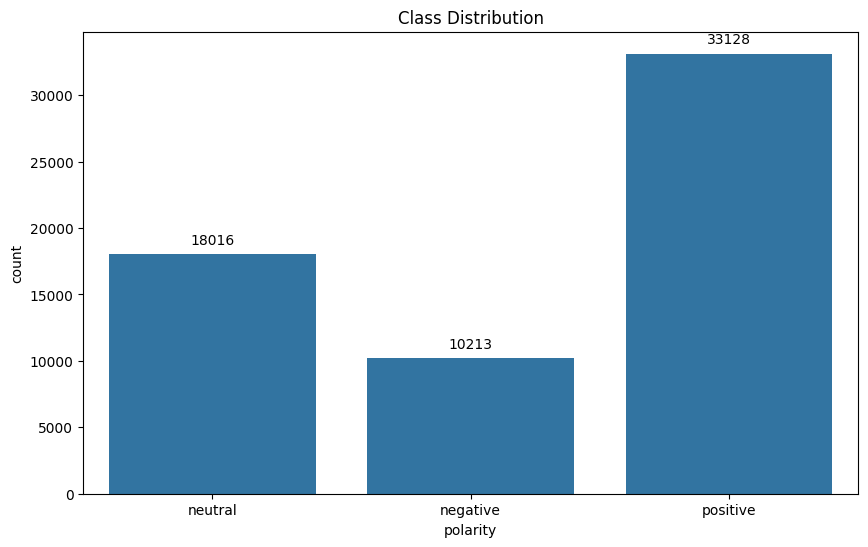

In [26]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

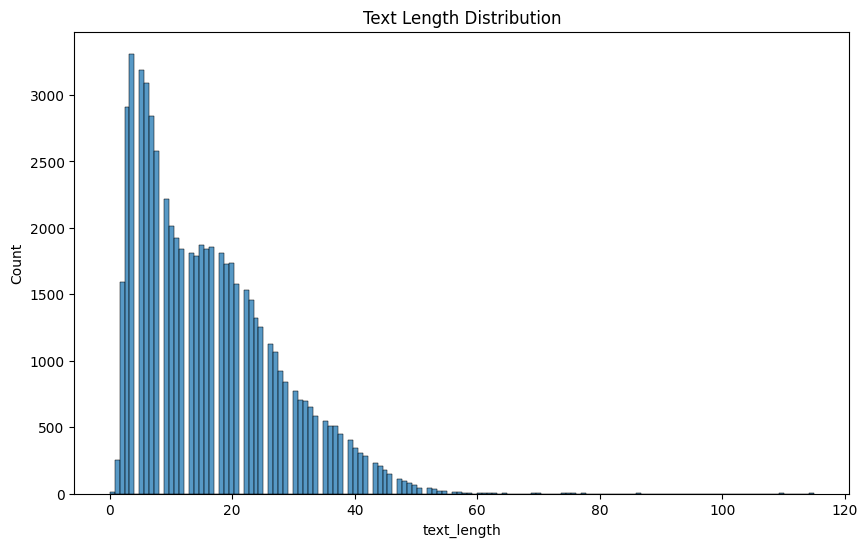

In [27]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()


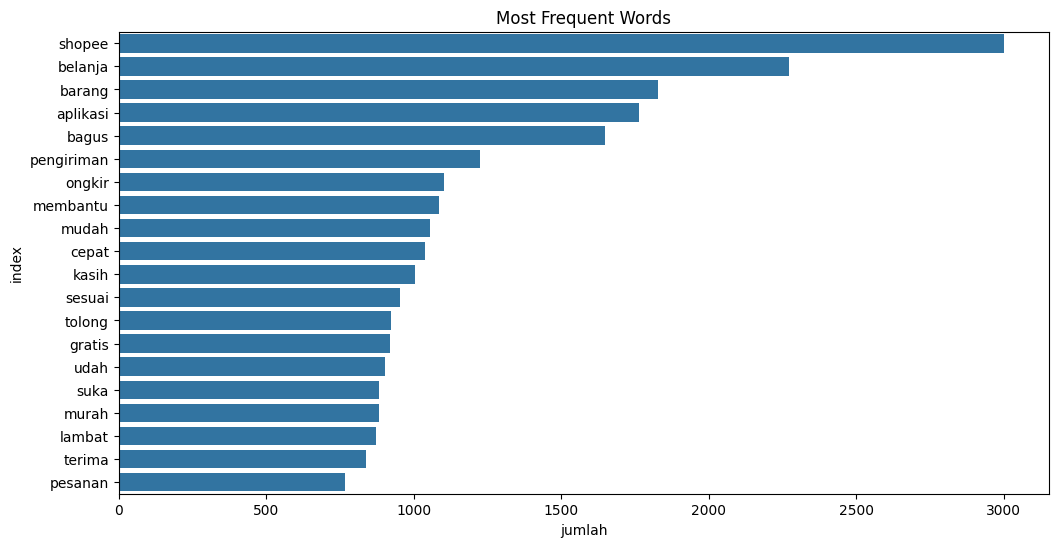

In [28]:
# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

## **Data Splitting**

In [29]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,697b441c-9de7-489e-a870-e07b88eed2ac,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"saya tidak suka dengan aplikasi shopee yg sekarang, saat buka aplikasi langsung ke menu live&video, itu bikin hp kentang saya makin ngelag. ulasan bintang 1 ini tidak akan saya ubah selama aplikasi saat dibuka langsung ke menu live&video. saya harap update selanjutnya saat buka aplikasi interface awal di menu beranda atau profil akun.",1,127,3.47.40,2025-04-10 11:48:12,"Hai kak Fitra Muhammad, terima kasih ya untuk feedbacknya. Kedepannya shopee akan terus berusaha lebih baik lagi agar para pengguna lebih nyaman dalam menggunakan shopee. Kalo ada pertanyaan/kendala, bisa hubungi DM Social Media twt @shopee_id / @shopeecare. Sehat selalu ^ZY",2025-04-10 12:35:26,3.47.40,saya tidak suka dengan aplikasi shopee yg sekarang saat buka aplikasi langsung ke menu livevideo itu bikin hp kentang saya makin ngelag ulasan bintang ini tidak akan saya ubah selama aplikasi saat dibuka langsung ke menu livevideo saya harap update selanjutnya saat buka aplikasi interface awal di menu beranda atau profil akun,saya tidak suka dengan aplikasi shopee yg sekarang saat buka aplikasi langsung ke menu livevideo itu bikin hp kentang saya makin ngelag ulasan bintang ini tidak akan saya ubah selama aplikasi saat dibuka langsung ke menu livevideo saya harap update selanjutnya saat buka aplikasi interface awal di menu beranda atau profil akun,saya tidak suka dengan aplikasi shopee yang sekarang saat buka aplikasi langsung ke menu livevideo itu membuat hp kentang saya makin ngelag ulasan bintang ini tidak akan saya ubah selama aplikasi saat dibuka langsung ke menu livevideo saya harap update selanjutnya saat buka aplikasi interface awal di menu beranda atau profil akun,"[saya, tidak, suka, dengan, aplikasi, shopee, yang, sekarang, saat, buka, aplikasi, langsung, ke, menu, livevideo, itu, membuat, hp, kentang, saya, makin, ngelag, ulasan, bintang, ini, tidak, akan, saya, ubah, selama, aplikasi, saat, dibuka, langsung, ke, menu, livevideo, saya, harap, update, selanjutnya, saat, buka, aplikasi, interface, awal, di, menu, beranda, atau, profil, akun]","[suka, aplikasi, shopee, buka, aplikasi, langsung, menu, livevideo, hp, kentang, ngelag, ulasan, bintang, ubah, aplikasi, dibuka, langsung, menu, livevideo, harap, update, buka, aplikasi, interface, menu, beranda, profil, akun]",suka aplikasi shopee buka aplikasi langsung menu livevideo hp kentang ngelag ulasan bintang ubah aplikasi dibuka langsung menu livevideo harap update buka aplikasi interface menu beranda profil akun,-7,neutral,28
1,2afeff66-3c72-4514-9b42-324732c66fb8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Status ""Dalam pengantaran"" tapi di tunggu gak ada kurir yang datang, tiba tiba status berubah""pengiriman ditunda: pembeli mengatur ulang jadwal pengiriman, maksudnya apalah, mana toko nya gak bisa di chat, bikin kesal aja, mana ada 3 pesanan, nnti klo udh selesai semua pemesanan mending di uninstall aja",2,13,3.47.40,2025-04-12 10:27:10,"Hai kak Dedes Ayss, maaf ya udah buat risau terkait kendala pesanan yang kakak alami. Agar dapat kami prioritaskan pengecekan, infoin kendala kamu melalui DM ke Media Sosial instagram @shopee_id / @shopeecare_id ya kak, Stay safe ^RU",2025-04-12 11:10:37,3.47.40,Status Dalam pengantaran tapi di tunggu gak ada kurir yang datang tiba tiba status berubahpengiriman ditunda pembeli mengatur ulang jadwal pengiriman maksudnya apalah mana toko nya gak bisa di chat bikin kesal aja mana ada pesanan nnti klo udh selesai semua pemesanan mending di uninstall aja,status 

In [30]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

## **1. Skema 1: SVM + TF-IDF + Split 80/20**

In [33]:
# Skema 1: SVM + TF-IDF + Split 80/20

# Ekstraksi fitur
tfidf = TfidfVectorizer(max_features=20000, min_df=17, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Training model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Evaluasi
y_test_pred = svm_model.predict(X_test)
y_train_pred=svm_model.predict(X_train)

accuracy_train_svm = accuracy_score(y_train, y_train_pred)
accuracy_test_svm = accuracy_score(y_test, y_test_pred)

print(f"Akurasi Train: {accuracy_train_svm:.4f}")
print(f"Akurasi Test: {accuracy_test_svm:.4f}")

Akurasi Train: 0.9121
Akurasi Test: 0.8692


## **2. Skema 2: RandomForest + SMOTE + TF-IDF + Split 80/20**

In [34]:
#Skema 2: RandomForest + SMOTE + TF-IDF + Split 80/20

# Ekstraksi fitur
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_tfidf = tfidf.fit_transform(X)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_tfidf, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

# Training Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)
y_train_pred=model.predict(X_train)

accuracy_train_rf = accuracy_score(y_train, y_train_pred)
accuracy_test_rf = accuracy_score(y_test, y_test_pred)

# Evaluasi
print(f"Akurasi Train: {accuracy_train_rf:.4f}")
print(f"Akurasi Test: {accuracy_test_rf:.4f}")

Akurasi Train: 1.0000
Akurasi Test: 0.8695


## **Neural Network**

In [35]:
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.921:
            print(f"\nVal accuracy telah mencapai {logs.get('val_accuracy'):.4f}, menghentikan pelatihan pada epoch {epoch+1}")
            self.model.stop_training = True

early_stopping = CustomCallback()

In [37]:
# Tokenizer, ubat teks menjadi angka
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

#kalimat menjadi urutan angka
sequences = tokenizer.texts_to_sequences(X)
padded_sequences = pad_sequences(sequences, padding='post', maxlen=200)

# Encoding Data menjadi Angka
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y_encoded, test_size=0.2, random_state=42
)

#Membuat Model
model = Sequential([
    Embedding(10000, 16, input_length=200),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax') # ada 3 karena terbagi menjadi 3 label
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)


loss, accuracy = model.evaluate(X_test, y_test)

print(f"Akurasi Test: {accuracy:.4f}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5363 - loss: 0.9927 - val_accuracy: 0.5449 - val_loss: 0.9645
Epoch 2/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5490 - loss: 0.9447 - val_accuracy: 0.6340 - val_loss: 0.7562
Epoch 3/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6586 - loss: 0.7211 - val_accuracy: 0.6726 - val_loss: 0.7372
Epoch 4/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7317 - loss: 0.6036 - val_accuracy: 0.7101 - val_loss: 0.5660
Epoch 5/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7894 - loss: 0.4989 - val_accuracy: 0.8216 - val_loss: 0.4682
Epoch 6/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8202 - loss: 0.4383 - val_accuracy: 0.8394 - val_loss: 0.4009
Epoch 7/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8453 - loss: 0.3885 - val_accuracy: 0.8408 - val_loss: 0.3730
Epoch 8/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8674 - loss: 0.3380 - v

In [38]:
# Menyimpan model yang sudah dilatih
model.save('sentiment_analysis_model.h5')

print("Model berhasil disimpan!")


Model berhasil disimpan!


In [41]:
# Ambil akurasi training terakhir dari training history
accuracy_train_dl = history.history['accuracy'][-1]

# Membuat DataFrame hasil akurasi
results_df = pd.DataFrame({
    'Model': ['SVM', 'Random Forest', 'Neural Network'],
    'Accuracy Train': [accuracy_train_svm, accuracy_train_rf, accuracy_train_dl],
    'Accuracy Test': [accuracy_test_svm, accuracy_test_rf, accuracy]
})

# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)


            Model  Accuracy Test
0             SVM       0.869214
1   Random Forest       0.869548
2  Neural Network       0.921610


In [42]:
# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)

            Model  Accuracy Test
2  Neural Network       0.921610
1   Random Forest       0.869548
0             SVM       0.869214


Dalam kasus Sentiment Analysis ini, algoritma Neutral Network mencapai akurasi tertinggi sebesar 92,16%. Oleh karena itu, algoritma Neutral Networks dipilih sebagai model utama yang akan digunakan untuk memprediksi sentimen pada kalimat-kalimat baru.

In [46]:
model = load_model('sentiment_analysis_model.h5')

# Fungsi untuk memprediksi sentimen kalimat baru
def predict_sentiment(sentence):
    # Tokenize dan ubah kalimat menjadi sequence
    sequence = tokenizer.texts_to_sequences([sentence])
    padded_sequence = pad_sequences(sequence, padding='post', maxlen=200)

    # Melakukan prediksi dengan model
    prediction = model.predict(padded_sequence)

    # Ambil kelas dengan probabilitas tertinggi
    predicted_class = prediction.argmax(axis=-1)[0]

    # Mapping label integer ke nama label (misalnya: 0 -> 'negative', 1 -> 'neutral', 2 -> 'positive')
    sentiment_label = le.inverse_transform([predicted_class])[0]

    return sentiment_label, prediction[0]

# Coba dengan kalimat baru
sentence = input("Masukkan kalimat baru di sini:")
sentiment_label, prediction = predict_sentiment(sentence)

print(f"Sentimen Kalimat Baru: {sentiment_label}")
print(f"Prediction probabilities: {prediction}")


Masukkan kalimat baru di sini:aplikasi buruk, tidak sesuai dengan estimasi sampai, pembatalan secara tiba tiba dari penjual
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Sentimen Kalimat Baru: negative
Prediction probabilities: [8.85732591e-01 1.14267275e-01 5.68101797e-08]


In [47]:
!pip freeze > requirements.txt


In [48]:
from google.colab import files
files.download('requirements.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>